In [1]:
!pip install optuna lightgbm catboost xgboost scikit-learn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.6 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics         import (precision_recall_curve, roc_auc_score,
                                     average_precision_score, recall_score,
                                     precision_score, f1_score, confusion_matrix,
                                     ConfusionMatrixDisplay)
from sklearn.pipeline        import Pipeline

from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [95]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [96]:
df = pd.read_csv('/content/final_pre-renewal_churn_dataset.csv')

In [97]:
print(f"Raw shape        : {df.shape}")
print(f"Columns          : {df.columns.tolist()}")
print(f"\nRenewal_Year distribution:")
print(df["Renewal_Year"].value_counts().sort_index())

print(f"\nYear-wise churn rate:")
print(df.groupby("Renewal_Year")["churn_label"].mean().apply(lambda x: f"{x:.2%}"))

Raw shape        : (112081, 61)
Columns          : ['Co_Ref', 'year_key', 'Renewal_Year', 'payment_timeframe_missing', 'Total_Renewal_Score_New', 'payment_unknown', 'Payment_Timeframe', 'Sustainability_Score', 'payment_is_bacs', 'Auto_Renewal_Score', 'Tenure_Scores', 'Current_World_Pay_Token', 'payment_is_card', 'Renewal_Score_At_Release', 'Proforma_Membership_Status', 'Discount_Amount', 'price_increase_pct', 'Gross', 'Proforma_Account_Stage', 'Audit_Status_Group', 'Current_Anchorings', 'Last_Band', 'price_change', 'Anchoring_Score', 'Proforma_World_Pay_Token', 'Tenure_Years', '#_of_Connection', 'is_new_customer', 'Last_Connections', 'Tenure_Group', 'rc_desire_cancel_desired_to_cancel_true', 'crm_contractor_suggested_leave', 'Current_Auto_Renewal_Flag', 'crm_contractor_sentiment_score', 'Amount', 'PQQNet', 'had_rc_interaction', 'rc_Membership_Renewal_Decision', 'payment_is_worldpay', 'Band', 'had_em_interaction', 'Connection_Group', 'crm_agent_chase_count', 'crm_negative_customer_exper

In [98]:
# STEP 2 — TRAIN / TEST SPLIT (Time-Based on renewal_month_year)

TARGET    = "churn_label"
DROP_COLS = ["Co_Ref", "year_key", "Renewal_Year", "renewal_month_year"]

# Check churn rate per renewal_month_year
print("Churn rate per renewal_month_year:")
month_stats = (
    df.groupby("renewal_month_year")["churn_label"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "churn_rate", "count": "n_rows"})
    .reset_index()
)

# Sort chronologically
month_stats["_sort"] = pd.to_datetime(month_stats["renewal_month_year"], format="%b-%Y")
month_stats = month_stats.sort_values("_sort").drop(columns="_sort")
month_stats["churn_rate"] = month_stats["churn_rate"].round(4)
print(month_stats.to_string(index=False))

overall_churn = df["churn_label"].mean()
print(f"\nOverall churn rate: {overall_churn:.4f}")


Churn rate per renewal_month_year:
renewal_month_year  churn_rate  n_rows
          Jan-2023      0.1164    2922
          Feb-2023      0.1222    3011
          Mar-2023      0.1263    3088
          Apr-2023      0.1078    2681
          May-2023      0.1394    2884
          Jun-2023      0.1292    3135
          Jul-2023      0.1486    2800
          Aug-2023      0.1377    2360
          Sep-2023      0.1237    2546
          Oct-2023      0.1432    2836
          Nov-2023      0.1145    3110
          Dec-2023      0.1028    1955
          Jan-2024      0.1216    3011
          Feb-2024      0.1091    3043
          Mar-2024      0.1118    3229
          Apr-2024      0.0931    2739
          May-2024      0.0872    2903
          Jun-2024      0.1026    3147
          Jul-2024      0.0871    2777
          Aug-2024      0.1029    2409
          Sep-2024      0.1082    2440
          Oct-2024      0.1069    2909
          Nov-2024      0.0923    3292
          Dec-2024      0.089

In [99]:
# STEP 2 — TRAIN / TEST SPLIT (renewal_month_year based)

TARGET    = "churn_label"
DROP_COLS = ["Co_Ref", "year_key", "Renewal_Year", "renewal_month_year"]

# Convert to datetime for chronological comparison
df["_sort_date"] = pd.to_datetime(df["renewal_month_year"], format="%b-%Y")

TRAIN_END  = pd.to_datetime("Dec-2024", format="%b-%Y")
TEST_START = pd.to_datetime("Jan-2025", format="%b-%Y")
TEST_END   = pd.to_datetime("Mar-2026", format="%b-%Y")  # drop Apr/May 2026

train_df = df[df["_sort_date"] <= TRAIN_END].copy()
test_df  = df[
    (df["_sort_date"] >= TEST_START) &
    (df["_sort_date"] <= TEST_END)
].copy()

# Drop sort helper
df.drop(columns=["_sort_date"], inplace=True)
train_df.drop(columns=["_sort_date"], inplace=True)
test_df.drop(columns=["_sort_date"], inplace=True)

# Drop identifier + split columns
X_train = train_df.drop(columns=[TARGET] + DROP_COLS, errors="ignore")
X_test  = test_df.drop(columns=[TARGET]  + DROP_COLS, errors="ignore")
y_train = train_df[TARGET].astype(int)
y_test  = test_df[TARGET].astype(int)

print(f"Train shape      : {X_train.shape}  | Churn rate: {y_train.mean():.4f}")
print(f"Test  shape      : {X_test.shape}   | Churn rate: {y_test.mean():.4f}")
print(f"\nTrain class counts:\n{y_train.value_counts()}")
print(f"\nTest  class counts:\n{y_test.value_counts()}")

SCALE_POS_WEIGHT = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nscale_pos_weight : {SCALE_POS_WEIGHT:.2f}")

# Verify churn rates are balanced
print(f"\nTrain months     : Jan-2023 → Dec-2024")
print(f"Test  months     : Jan-2025 → Mar-2026")
print(f"Churn rate gap   : {abs(y_train.mean() - y_test.mean()):.4f}")

Train shape      : (67220, 56)  | Churn rate: 0.1138
Test  shape      : (44440, 56)   | Churn rate: 0.0973

Train class counts:
churn_label
0    59570
1     7650
Name: count, dtype: int64

Test  class counts:
churn_label
0    40117
1     4323
Name: count, dtype: int64

scale_pos_weight : 7.79

Train months     : Jan-2023 → Dec-2024
Test  months     : Jan-2025 → Mar-2026
Churn rate gap   : 0.0165


In [100]:
# STEP 3 — LABEL ENCODE CATEGORICALS

cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"Categorical columns: {cat_cols}")

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    # Handle unseen labels in test gracefully
    X_test[col]  = X_test[col].astype(str).map(
        lambda x, le=le: le.transform([x])[0]
        if x in le.classes_ else -1
    )
    label_encoders[col] = le

print(f"Encoded {len(cat_cols)} columns.")
print(f"Final feature count: {X_train.shape[1]}")

Categorical columns: ['Proforma_Membership_Status', 'Discount_Amount', 'Proforma_Account_Stage', 'Audit_Status_Group', 'Last_Band', 'Tenure_Group', 'Band', 'Connection_Group', 'Anchor_Group']
Encoded 9 columns.
Final feature count: 56


In [120]:
from sklearn.metrics import (precision_recall_curve, roc_auc_score,
                                     average_precision_score, recall_score,
                                     precision_score, f1_score, confusion_matrix,
                                     ConfusionMatrixDisplay, accuracy_score)

def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name,
                   threshold=0.6, verbose=True):
    """
    Train model, evaluate on test set.
    Returns dict of metrics.
    """
    model.fit(X_tr, y_tr)
    probs = model.predict_proba(X_te)[:, 1]
    preds = (probs >= threshold).astype(int)

    pr_auc    = average_precision_score(y_te, probs)
    roc_auc   = roc_auc_score(y_te, probs)
    recall    = recall_score(y_te, preds)
    precision = precision_score(y_te, preds, zero_division=0)
    f1        = f1_score(y_te, preds)
    accuracy  = accuracy_score(y_te, preds)

    if verbose:
        print(f"\n  {model_name}")
        print(f"  PR-AUC    : {pr_auc:.4f} ")
        print(f"  ROC-AUC   : {roc_auc:.4f}")
        print(f"  Recall    : {recall:.4f}")
        print(f"  Precision : {precision:.4f}")
        print(f"  F1-Score  : {f1:.4f}")
        print(f"  Accuracy  : {accuracy:.4f}")


    return {
        "model_name" : model_name,
        "model"      : model,
        "probs"      : probs,
        "pr_auc"     : pr_auc,
        "roc_auc"    : roc_auc,
        "recall"     : recall,
        "precision"  : precision,
        "f1"         : f1,
        "accuracy"   : accuracy
    }

In [103]:
from sklearn.impute import SimpleImputer
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()

imputer = SimpleImputer(strategy='mean')
X_train[num_cols] = imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = imputer.transform(X_test[num_cols])

print("NaNs in X_train:")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

print("\nNaNs in X_test:")
print(X_test.isnull().sum()[X_test.isnull().sum() > 0])

if X_train.isnull().sum().sum() == 0 and X_test.isnull().sum().sum() == 0:
    print("\nNo NaN values found in X_train and X_test after imputation. Proceeding with model training.")
else:
    print("\nWarning: NaN values still present after imputation. Please investigate.")

NaNs in X_train:
Series([], dtype: int64)

NaNs in X_test:
Series([], dtype: int64)

No NaN values found in X_train and X_test after imputation. Proceeding with model training.


In [77]:
X_train.columns.to_list()

['payment_timeframe_missing',
 'Total_Renewal_Score_New',
 'payment_unknown',
 'Payment_Timeframe',
 'Sustainability_Score',
 'payment_is_bacs',
 'Auto_Renewal_Score',
 'Tenure_Scores',
 'Current_World_Pay_Token',
 'payment_is_card',
 'Renewal_Score_At_Release',
 'Proforma_Membership_Status',
 'Discount_Amount',
 'price_increase_pct',
 'Gross',
 'Proforma_Account_Stage',
 'Audit_Status_Group',
 'Current_Anchorings',
 'Last_Band',
 'price_change',
 'Anchoring_Score',
 'Proforma_World_Pay_Token',
 'Tenure_Years',
 '#_of_Connection',
 'is_new_customer',
 'Last_Connections',
 'Tenure_Group',
 'rc_desire_cancel_desired_to_cancel_true',
 'crm_contractor_suggested_leave',
 'Current_Auto_Renewal_Flag',
 'crm_contractor_sentiment_score',
 'Amount',
 'PQQNet',
 'had_rc_interaction',
 'rc_Membership_Renewal_Decision',
 'payment_is_worldpay',
 'Band',
 'had_em_interaction',
 'Connection_Group',
 'crm_agent_chase_count',
 'crm_negative_customer_experience',
 'Anchor_Group',
 'crm_financial_hardship

In [117]:
final_drops = [
    "payment_timeframe_missing",       # perfect target copy
    "payment_unknown",                 # 100% churn post-outcome recording
    "crm_contractor_suggested_leave",  # zero variance in train set
    "crm_contractor_sentiment_score",# zero variance in train set
    "Payment_Timeframe",
    "payment_is_bacs",
    "payment_is_card",
    "payment_is_worldplay"

]

X_train = X_train.drop(columns=final_drops, errors="ignore")
X_test  = X_test.drop(columns=final_drops, errors="ignore")

print(f"Features remaining: {X_train.shape[1]}")

Features remaining: 49


STAGE 1 — INDIVIDUAL MODELS

>>> Logistic Regression (Baseline)

  Logistic Regression
  PR-AUC    : 0.7698 
  ROC-AUC   : 0.9658
  Recall    : 0.8781
  Precision : 0.5356
  F1-Score  : 0.6653
  Accuracy  : 0.9141

>>> Random Forest

  Random Forest
  PR-AUC    : 0.8988 
  ROC-AUC   : 0.9767
  Recall    : 0.8638
  Precision : 0.7363
  F1-Score  : 0.7950
  Accuracy  : 0.9567

>>> XGBoost

  XGBoost
  PR-AUC    : 0.8163 
  ROC-AUC   : 0.9688
  Recall    : 0.8499
  Precision : 0.6160
  F1-Score  : 0.7143
  Accuracy  : 0.9339

>>> LightGBM

  LightGBM
  PR-AUC    : 0.8551 
  ROC-AUC   : 0.9733
  Recall    : 0.8941
  Precision : 0.6135
  F1-Score  : 0.7277
  Accuracy  : 0.9349

>>> CatBoost

  CatBoost
  PR-AUC    : 0.8647 
  ROC-AUC   : 0.9686
  Recall    : 0.8656
  Precision : 0.6068
  F1-Score  : 0.7134
  Accuracy  : 0.9324

STAGE 1 SUMMARY — Ranked by F1
              Model     F1  Precision  Recall  PR-AUC  ROC-AUC  Accuracy
      Random Forest 0.7950     0.7363  0.8638  0.8988   0.976

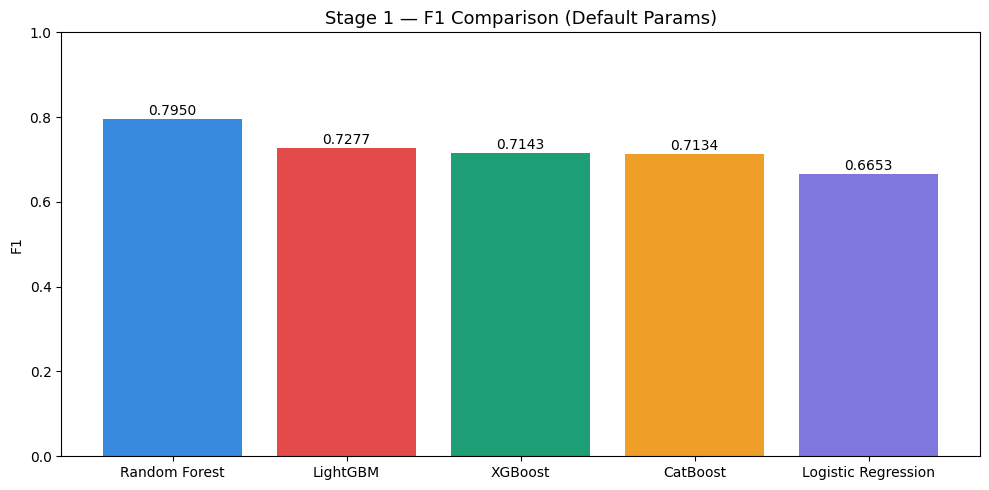

In [122]:
print("STAGE 1 — INDIVIDUAL MODELS")

stage1_results = []

# ── 1a. Logistic Regression (Baseline) ───────────────────────────────────────
print("\n>>> Logistic Regression (Baseline)")

# LR needs scaling — wrap in pipeline
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])
res = evaluate_model(lr_pipeline, X_train, y_train,
                     X_test, y_test, "Logistic Regression")
stage1_results.append(res)

# ── 1b. Random Forest ─────────────────────────────────────────────────────────
print("\n>>> Random Forest")

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
res = evaluate_model(rf, X_train, y_train,
                     X_test, y_test, "Random Forest")
stage1_results.append(res)

# ── 1c. XGBoost ───────────────────────────────────────────────────────────────
print("\n>>> XGBoost")

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    scale_pos_weight=SCALE_POS_WEIGHT,
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
res = evaluate_model(xgb, X_train, y_train,
                     X_test, y_test, "XGBoost")
stage1_results.append(res)

# ── 1d. LightGBM ──────────────────────────────────────────────────────────────
print("\n>>> LightGBM")

lgbm = LGBMClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
res = evaluate_model(lgbm, X_train, y_train,
                     X_test, y_test, "LightGBM")
stage1_results.append(res)

# ── 1e. CatBoost ──────────────────────────────────────────────────────────────
print("\n>>> CatBoost")

cat_features_idx = [X_train.columns.get_loc(c) for c in cat_cols
                    if c in X_train.columns]

cb = CatBoostClassifier(
    iterations=300,
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=0
)
res = evaluate_model(cb, X_train, y_train,
                     X_test, y_test, "CatBoost")
stage1_results.append(res)

# ── Stage 1 Summary ───────────────────────────────────────────────────────────
stage1_df = pd.DataFrame([
    {
        "Model"    : r["model_name"],
        "F1"       : round(r["f1"],       4),
        "Precision": round(r["precision"],4),
        "Recall"   : round(r["recall"],   4),
        "PR-AUC"   : round(r["pr_auc"],   4),
        "ROC-AUC"  : round(r["roc_auc"],  4),
        "Accuracy" : round(r["accuracy"], 4)
    } for r in stage1_results
]).sort_values("F1", ascending=False)

print("\n" + "=" * 60)
print("STAGE 1 SUMMARY — Ranked by F1")
print("=" * 60)
print(stage1_df.to_string(index=False))

# Pick top 2 for tuning
top2_names = stage1_df.head(2)["Model"].tolist()
print(f"\nTop 2 for tuning: {top2_names}")

# Stage 1 bar chart
plt.figure(figsize=(10, 5))
colors = ["#378ADD", "#E24B4A", "#1D9E75", "#EF9F27", "#7F77DD"]
bars = plt.bar(stage1_df["Model"], stage1_df["F1"], color=colors)
plt.title("Stage 1 — F1 Comparison (Default Params)", fontsize=13)
plt.ylabel("F1")
plt.ylim(0, 1)
for bar, val in zip(bars, stage1_df["F1"]):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01, f"{val:.4f}",
             ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("stage1_comparison.png", dpi=150)
plt.show()

In [115]:
import shap
print("\nCalculating SHAP values")

explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_test)

# For binary classification, shap_values[1] contains values for the positive class (Churned=1)
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
else:
    shap_values_pos = shap_values


Calculating SHAP values



=== TOP 15 FEATURES BY MEAN ABSOLUTE SHAP (Highest Impact) ===
                       feature  mean_abs_shap
1            Payment_Timeframe       4.074104
5                Tenure_Scores       1.945364
3              payment_is_bacs       1.639376
7              payment_is_card       1.567770
0      Total_Renewal_Score_New       1.525449
22             is_new_customer       1.186553
16                   Last_Band       1.035593
20                Tenure_Years       0.395879
19    Proforma_World_Pay_Token       0.310043
31         payment_is_worldpay       0.266023
8     Renewal_Score_At_Release       0.263093
21             #_of_Connection       0.212151
12                       Gross       0.207529
9   Proforma_Membership_Status       0.204135
10             Discount_Amount       0.204022


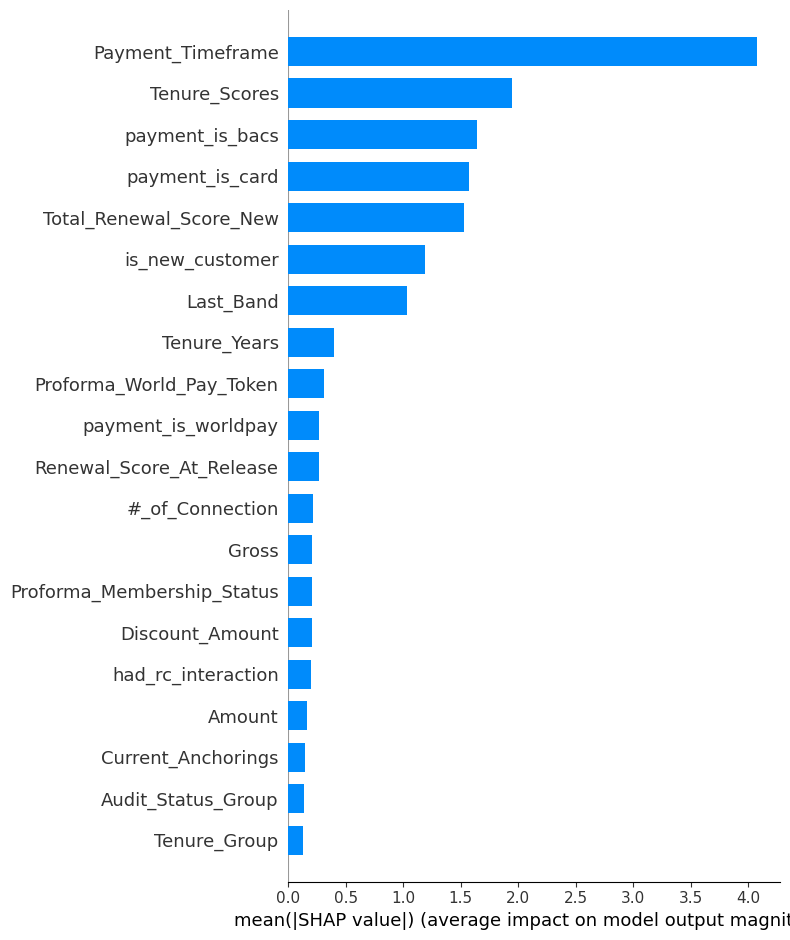

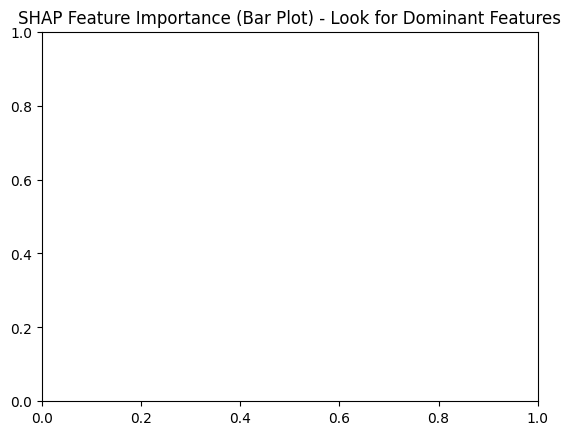

In [116]:
# ====================== 4. SHAP Summary for Leakage Detection ======================
print("\n=== TOP 15 FEATURES BY MEAN ABSOLUTE SHAP (Highest Impact) ===")

# Calculate mean absolute SHAP value per feature
mean_abs_shap = np.abs(shap_values_pos).mean(axis=0)
shap_importance = pd.DataFrame({
    'feature': X_train.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

print(shap_importance.head(15))

# ====================== 5. Plot SHAP Summary (Beeswarm) ======================
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_pos, X_test, plot_type="bar", max_display=20)
plt.title("SHAP Feature Importance (Bar Plot) - Look for Dominant Features")
plt.show()

## **Check for data leakage**

In [13]:
print(df["rc_Membership_Renewal_Decision"].value_counts())
print("\nChurn rate per value:")
print(df.groupby("rc_Membership_Renewal_Decision")["churn_label"].mean())

rc_Membership_Renewal_Decision
0.0    110127
1.0      1954
Name: count, dtype: int64

Churn rate per value:
rc_Membership_Renewal_Decision
0.0    0.097569
1.0    0.643296
Name: churn_label, dtype: float64


In [14]:
print("PROPER LEAKAGE CHECK")
print("=" * 60)

for col in X_train.columns:
    churn_rates = df.groupby(col)["churn_label"].mean()
    counts      = df.groupby(col)["churn_label"].count()

    # Only flag if:
    # 1. A value has 100% or 0% churn AND
    # 2. That value covers a significant portion of data (>5%) AND
    # 3. There are very few unique values (not a continuous column)

    n_unique     = df[col].nunique()
    total_rows   = len(df)

    for val, rate in churn_rates.items():
        group_size = counts[val]
        group_pct  = group_size / total_rows * 100

        if (rate == 1.0 or rate == 0.0) and group_pct > 5 and n_unique < 20:
            print(f"🚨 REAL LEAKAGE RISK: {col}")
            print(f"   Value={val} | Churn rate={rate:.2f} "
                  f"| Rows={group_size} ({group_pct:.1f}%)")
            break

PROPER LEAKAGE CHECK
🚨 REAL LEAKAGE RISK: payment_is_bacs
   Value=1 | Churn rate=0.00 | Rows=32810 (29.3%)


In [15]:
# Find which single feature perfectly separates classes
print("PERFECT SEPARATOR CHECK")
print("=" * 60)

for col in X_train.columns:
    # Check correlation with target
    if X_train[col].nunique() <= 50:
        rates = df.groupby(col)["churn_label"].mean()
        count_at_1 = df.groupby(col)["churn_label"].count() # Calculate counts here to ensure alignment

        if (rates == 1.0).any() and rates[rates == 1.0].index.tolist():
            for val in rates[rates == 1.0].index:
                if val in count_at_1.index: # Added check for key existence
                    pct = count_at_1[val] / len(df) * 100
                    if pct > 1.0:   # more than 1% of data
                        print(f"🚨 {col} = {val} → 100% churn "
                              f"| {count_at_1[val]:,} rows ({pct:.1f}%)")
        if (rates == 0.0).any():
            for val in rates[rates == 0.0].index:
                if val in count_at_1.index: # Added check for key existence
                    pct = count_at_1[val] / len(df) * 100
                    if pct > 1.0:
                        print(f"🚨 {col} = {val} → 0% churn  "
                              f"| {count_at_1[val]:,} rows ({pct:.1f}%)")

PERFECT SEPARATOR CHECK
🚨 payment_is_bacs = 1 → 0% churn  | 32,810 rows (29.3%)
🚨 payment_is_worldpay = 1 → 0% churn  | 1,682 rows (1.5%)


In [16]:
# Check what's left that's highly correlated
print("REMAINING HIGH CORRELATION CHECK")
print("=" * 60)

correlations = []
for col in X_train.columns:
    try:
        corr = abs(pd.to_numeric(X_train[col], errors='coerce')
                   .corr(y_train))
        correlations.append((col, round(corr, 4)))
    except:
        pass

correlations.sort(key=lambda x: x[1], reverse=True)
print(f"{'Feature':<60} {'|Correlation|'}")
print("-" * 70)
for col, corr in correlations[:20]:  # top 20
    print(f"{col:<60} {corr}")

REMAINING HIGH CORRELATION CHECK
Feature                                                      |Correlation|
----------------------------------------------------------------------
Tenure_Scores                                                0.4657
is_new_customer                                              0.3902
Discount_Amount                                              0.349
price_increase_pct                                           0.3123
Proforma_Membership_Status                                   0.2871
Current_World_Pay_Token                                      0.2477
price_change                                                 0.2457
Anchoring_Score                                              0.2335
payment_is_bacs                                              0.2042
Tenure_Group                                                 0.1827
Gross                                                        0.1739
rc_Membership_Renewal_Decision                               0.1739
Tenure

## **Hyperparameter tuning**

In [53]:
from sklearn.metrics import f1_score as sk_f1, average_precision_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
N_TRIALS = 20

tuned_models    = {}
best_params_log = {}

# ── Tune XGBoost if in top 2 ──────────────────────────────────────────────────
if "XGBoost" in top2_names:
    print("\n>>> Tuning XGBoost...")

    def xgb_objective(trial):
        params = {
            "n_estimators"    : trial.suggest_int("n_estimators", 200, 600),
            "max_depth"       : trial.suggest_int("max_depth", 4, 10),
            "learning_rate"   : trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "subsample"       : trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "scale_pos_weight": trial.suggest_float("scale_pos_weight", 6.0, 12.0),
            "eval_metric"     : "aucpr",
            "random_state"    : 42,
            "verbosity"       : 0,
            "n_jobs"          : -1
        }
        model  = XGBClassifier(**params)
        scores = []
        for tr_idx, val_idx in cv.split(X_train, y_train):
            X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
            model.fit(X_tr, y_tr)
            probs = model.predict_proba(X_val)[:, 1]           # ← changed
            scores.append(average_precision_score(y_val, probs))  # ← changed
        return np.mean(scores)

    xgb_study = optuna.create_study(direction="maximize")
    xgb_study.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

    best_xgb_params = xgb_study.best_params
    best_params_log["XGBoost"] = best_xgb_params
    print(f"\nBest XGBoost params : {best_xgb_params}")
    print(f"Best CV PR-AUC      : {xgb_study.best_value:.4f}")   # ← changed

    tuned_xgb = XGBClassifier(**best_xgb_params, random_state=42,
                               verbosity=0, n_jobs=-1)
    tuned_xgb.fit(X_train, y_train)
    tuned_models["XGBoost"] = tuned_xgb

# ── Tune LightGBM if in top 2 ─────────────────────────────────────────────────
if "LightGBM" in top2_names:
    print("\n>>> Tuning LightGBM...")

    def lgbm_objective(trial):
        params = {
            "n_estimators"     : trial.suggest_int("n_estimators", 200, 600),
            "num_leaves"       : trial.suggest_int("num_leaves", 20, 150),
            "max_depth"        : trial.suggest_int("max_depth", 4, 12),
            "learning_rate"    : trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
            "feature_fraction" : trial.suggest_float("feature_fraction", 0.6, 1.0),
            "bagging_fraction" : trial.suggest_float("bagging_fraction", 0.6, 1.0),
            "bagging_freq"     : 1,
            "class_weight"     : "balanced",
            "random_state"     : 42,
            "verbose"          : -1,
            "n_jobs"           : -1
        }
        model  = LGBMClassifier(**params)
        scores = []
        for tr_idx, val_idx in cv.split(X_train, y_train):
            X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
            model.fit(X_tr, y_tr)
            probs = model.predict_proba(X_val)[:, 1]           # ← changed
            scores.append(average_precision_score(y_val, probs))  # ← changed
        return np.mean(scores)

    lgbm_study = optuna.create_study(direction="maximize")
    lgbm_study.optimize(lgbm_objective, n_trials=N_TRIALS, show_progress_bar=True)

    best_lgbm_params = lgbm_study.best_params
    best_params_log["LightGBM"] = best_lgbm_params
    print(f"\nBest LightGBM params : {best_lgbm_params}")
    print(f"Best CV PR-AUC       : {lgbm_study.best_value:.4f}")  # ← changed

    tuned_lgbm = LGBMClassifier(**best_lgbm_params, random_state=42,
                                 verbose=-1, n_jobs=-1)
    tuned_lgbm.fit(X_train, y_train)
    tuned_models["LightGBM"] = tuned_lgbm

# ── Tune CatBoost if in top 2 ─────────────────────────────────────────────────
if "CatBoost" in top2_names:
    print("\n>>> Tuning CatBoost...")

    def cb_objective(trial):
        params = {
            "iterations"        : trial.suggest_int("iterations", 200, 600),
            "depth"             : trial.suggest_int("depth", 4, 10),
            "learning_rate"     : trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "l2_leaf_reg"       : trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
            "auto_class_weights": "Balanced",
            "random_seed"       : 42,
            "verbose"           : 0
        }
        model  = CatBoostClassifier(**params)
        scores = []
        for tr_idx, val_idx in cv.split(X_train, y_train):
            X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
            model.fit(X_tr, y_tr)
            probs = model.predict_proba(X_val)[:, 1]           # ← changed
            scores.append(average_precision_score(y_val, probs))  # ← changed
        return np.mean(scores)

    cb_study = optuna.create_study(direction="maximize")
    cb_study.optimize(cb_objective, n_trials=N_TRIALS, show_progress_bar=True)

    best_cb_params = cb_study.best_params
    best_params_log["CatBoost"] = best_cb_params
    print(f"\nBest CatBoost params : {best_cb_params}")
    print(f"Best CV PR-AUC       : {cb_study.best_value:.4f}")    # ← changed

    tuned_cb = CatBoostClassifier(**best_cb_params,
                                   random_seed=42, verbose=0)
    tuned_cb.fit(X_train, y_train)
    tuned_models["CatBoost"] = tuned_cb

# =============================================================================
# STAGE 2 EVALUATION + THRESHOLD TUNING FOR F1
# =============================================================================

print("\n" + "=" * 60)
print("STAGE 2 — TUNED MODEL EVALUATION + THRESHOLD TUNING")
print("=" * 60)

# ── Get one validation fold for threshold tuning ──────────────────────────────
# Use last fold — never use test set for this
for tr_idx, val_idx in cv.split(X_train, y_train):
    pass  # iterates to last fold

X_val_thr = X_train.iloc[val_idx]
y_val_thr = y_train.iloc[val_idx]

stage2_results = []

for name, model in tuned_models.items():

    # ── Threshold tuning on validation fold ───────────────────────────────────
    val_probs  = model.predict_proba(X_val_thr)[:, 1]
    thresholds = np.arange(0.1, 0.9, 0.01)
    f1_scores  = []

    for thr in thresholds:
        preds_thr = (val_probs >= thr).astype(int)
        f1_scores.append(sk_f1(y_val_thr, preds_thr, zero_division=0))

    best_thr    = thresholds[np.argmax(f1_scores)]
    best_val_f1 = max(f1_scores)
    print(f"\n  {name} → optimal threshold : {best_thr:.2f}"
          f" | val F1 : {best_val_f1:.4f}")

    # ── Final evaluation on test set at optimal threshold ─────────────────────
    test_probs  = model.predict_proba(X_test)[:, 1]
    test_preds  = (test_probs >= best_thr).astype(int)

    pr_auc    = average_precision_score(y_test, test_probs)
    roc_auc   = roc_auc_score(y_test, test_probs)
    recall    = recall_score(y_test, test_preds)
    precision = precision_score(y_test, test_preds, zero_division=0)
    f1        = sk_f1(y_test, test_preds, zero_division=0)

    print(f"  {name} (Tuned) — Test Set @ threshold {best_thr:.2f}")
    print(f"  PR-AUC    : {pr_auc:.4f}   ← primary model quality")
    print(f"  ROC-AUC   : {roc_auc:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  Precision : {precision:.4f}")
    print(f"  F1-Score  : {f1:.4f}   ← at optimal threshold")

    stage2_results.append({
        "model_name" : f"{name} (Tuned)",
        "model"      : model,
        "probs"      : test_probs,
        "threshold"  : best_thr,
        "pr_auc"     : pr_auc,
        "roc_auc"    : roc_auc,
        "recall"     : recall,
        "precision"  : precision,
        "f1"         : f1
    })

# ── Stage 2 Summary ───────────────────────────────────────────────────────────
stage2_df = pd.DataFrame([{
    "Model"    : r["model_name"],
    "Threshold": r["threshold"],
    "PR-AUC"   : round(r["pr_auc"],   4),
    "ROC-AUC"  : round(r["roc_auc"],  4),
    "Recall"   : round(r["recall"],   4),
    "Precision": round(r["precision"],4),
    "F1"       : round(r["f1"],       4),
} for r in stage2_results]).sort_values("PR-AUC", ascending=False)

print("\n" + "=" * 60)
print("STAGE 2 SUMMARY — Ranked by PR-AUC")
print("=" * 60)
print(stage2_df.to_string(index=False))

best_individual = max(stage2_results, key=lambda x: x["pr_auc"])
print(f"\nBest individual : {best_individual['model_name']}"
      f" | PR-AUC : {best_individual['pr_auc']:.4f}"
      f" | F1 : {best_individual['f1']:.4f}"
      f" | Threshold : {best_individual['threshold']:.2f}")


>>> Tuning LightGBM...


  0%|          | 0/20 [00:00<?, ?it/s]


Best LightGBM params : {'n_estimators': 546, 'num_leaves': 26, 'max_depth': 6, 'learning_rate': 0.025119549520523466, 'min_child_samples': 36, 'feature_fraction': 0.6827632089655639, 'bagging_fraction': 0.9351758934555475}
Best CV PR-AUC       : 0.9989

>>> Tuning CatBoost...


  0%|          | 0/20 [00:00<?, ?it/s]


Best CatBoost params : {'iterations': 315, 'depth': 6, 'learning_rate': 0.09218384141363646, 'l2_leaf_reg': 1.1706397321904223}
Best CV PR-AUC       : 0.9990

STAGE 2 — TUNED MODEL EVALUATION + THRESHOLD TUNING

  LightGBM → optimal threshold : 0.61 | val F1 : 0.9964
  LightGBM (Tuned) — Test Set @ threshold 0.61
  PR-AUC    : 0.9967   ← primary model quality
  ROC-AUC   : 0.9996
  Recall    : 0.9956
  Precision : 0.8066
  F1-Score  : 0.8912   ← at optimal threshold

  CatBoost → optimal threshold : 0.52 | val F1 : 0.9971
  CatBoost (Tuned) — Test Set @ threshold 0.52
  PR-AUC    : 0.9887   ← primary model quality
  ROC-AUC   : 0.9987
  Recall    : 0.9928
  Precision : 0.7877
  F1-Score  : 0.8784   ← at optimal threshold

STAGE 2 SUMMARY — Ranked by PR-AUC
           Model  Threshold  PR-AUC  ROC-AUC  Recall  Precision     F1
LightGBM (Tuned)       0.61  0.9967   0.9996  0.9956     0.8066 0.8912
CatBoost (Tuned)       0.52  0.9887   0.9987  0.9928     0.7877 0.8784

Best individual : 

## **Validation Data Leakage check**

In [56]:
# Check top feature importances from tuned LightGBM
importance = pd.Series(
    tuned_lgbm.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("TOP 10 FEATURES — Tuned LightGBM")
print("=" * 50)
print(importance.head(10))

# Check top 3 features individually
for feat in importance.head(3).index:
    corr = abs(pd.to_numeric(X_train[feat], errors='coerce').corr(y_train))
    rates = pd.concat([X_train[feat], y_train], axis=1)
    rates_grp = rates.groupby(feat)["churn_label"].mean()
    print(f"\n{feat} | correlation={corr:.4f}")
    print(rates_grp.sort_values(ascending=False).head(5))

TOP 10 FEATURES — Tuned LightGBM
Tenure_Years                1769
Tenure_Scores               1444
Total_Renewal_Score_New     1355
Payment_Timeframe            804
Renewal_Score_At_Release     560
Gross                        526
is_new_customer              504
Proforma_World_Pay_Token     452
Last_Band                    439
price_increase_pct           437
dtype: int32

Tenure_Years | correlation=0.1726
Tenure_Years
0.0     0.837838
24.0    0.333333
1.0     0.214759
2.0     0.161512
3.0     0.155269
Name: churn_label, dtype: float64

Tenure_Scores | correlation=0.4657
Tenure_Scores
7.5    0.969341
8.0    0.501105
7.0    0.428571
8.5    0.109606
9.0    0.072440
Name: churn_label, dtype: float64

Total_Renewal_Score_New | correlation=0.6315
Total_Renewal_Score_New
31.0    0.997628
32.0    0.701085
31.5    0.552434
30.5    0.531250
32.5    0.504644
Name: churn_label, dtype: float64


In [57]:
# Quick experiment — drop suspected score columns
suspect_scores = ["Total_Renewal_Score_New", "Tenure_Scores"]

X_train_exp = X_train.drop(columns=suspect_scores, errors="ignore")
X_test_exp  = X_test.drop(columns=suspect_scores,  errors="ignore")

lgbm_exp = LGBMClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    verbose=-1
)
lgbm_exp.fit(X_train_exp, y_train)

probs_exp = lgbm_exp.predict_proba(X_test_exp)[:, 1]
preds_exp = (probs_exp >= 0.5).astype(int)

print("WITHOUT suspect score columns:")
print(f"PR-AUC    : {average_precision_score(y_test, probs_exp):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, probs_exp):.4f}")
print(f"Recall    : {recall_score(y_test, preds_exp):.4f}")
print(f"Precision : {precision_score(y_test, preds_exp, zero_division=0):.4f}")
print(f"F1        : {sk_f1(y_test, preds_exp, zero_division=0):.4f}")

# Compare importance without them
importance_exp = pd.Series(
    lgbm_exp.feature_importances_,
    index=X_train_exp.columns
).sort_values(ascending=False)

print("\nTop 10 features without score columns:")
print(importance_exp.head(10))

WITHOUT suspect score columns:
PR-AUC    : 0.9996
ROC-AUC   : 1.0000
Recall    : 1.0000
Precision : 0.7128
F1        : 0.8323

Top 10 features without score columns:
Tenure_Years                1064
Gross                       1051
Renewal_Score_At_Release     901
Amount                       769
Current_Anchorings           619
price_increase_pct           415
#_of_Connection              367
price_change                 343
Audit_Status_Group           314
Proforma_World_Pay_Token     255
dtype: int32


In [58]:
# Check Renewal_Score_At_Release
corr = abs(pd.to_numeric(X_train["Renewal_Score_At_Release"],
           errors='coerce').corr(y_train))

rates = pd.concat(
    [X_train["Renewal_Score_At_Release"], y_train], axis=1
)
grp = rates.groupby("Renewal_Score_At_Release")["churn_label"].mean()
counts = rates.groupby("Renewal_Score_At_Release")["churn_label"].count()

print(f"Renewal_Score_At_Release | correlation = {corr:.4f}")
print(f"\nChurn rate at each value (sorted by churn rate):")
summary = pd.DataFrame({
    "churn_rate": grp,
    "count": counts
}).sort_values("churn_rate", ascending=False)
print(summary.head(20))

# Also check ALL remaining score columns together
score_cols = [
    "Renewal_Score_At_Release",
    "Auto_Renewal_Score",
    "Anchoring_Score",
    "Sustainability_Score",
    "Proforma_World_Pay_Token",
    "Current_World_Pay_Token"
]

print("\nCorrelation of all score columns with target:")
for col in score_cols:
    if col in X_train.columns:
        corr = abs(pd.to_numeric(
            X_train[col], errors='coerce').corr(y_train)
        )
        max_churn = pd.concat(
            [X_train[col], y_train], axis=1
        ).groupby(col)["churn_label"].mean().max()
        print(f"  {col:<35} corr={corr:.4f}  max_churn_rate={max_churn:.4f}")

Renewal_Score_At_Release | correlation = 0.3297

Churn rate at each value (sorted by churn rate):
                          churn_rate  count
Renewal_Score_At_Release                   
15.5                        1.000000      1
16.5                        1.000000      1
21.0                        0.520062    648
22.7                        0.500000      2
21.5                        0.406316   1425
20.5                        0.404040    297
22.0                        0.378512   1210
22.5                        0.351909   2279
23.0                        0.262658   2844
23.5                        0.204529   2782
24.0                        0.201514   3434
24.5                        0.143341   5609
25.0                        0.123994   3726
25.5                        0.099642   5028
24.2                        0.083333     12
26.0                        0.073877   6768
24.7                        0.071429     42
25.2                        0.069767     86
26.5                  

In [59]:
# Shuffle the target randomly — if model still gets high score
# then we definitely have leakage
# If score drops to ~0.1 (baseline) then results are genuine

import numpy as np
from sklearn.metrics import average_precision_score

y_train_shuffled = y_train.sample(frac=1, random_state=42).reset_index(drop=True)

lgbm_sanity = LGBMClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    verbose=-1
)
lgbm_sanity.fit(X_train, y_train_shuffled)
probs_sanity = lgbm_sanity.predict_proba(X_test)[:, 1]

print("SANITY CHECK — Shuffled Target")
print(f"PR-AUC with REAL target    : 0.9967")
print(f"PR-AUC with SHUFFLED target: "
      f"{average_precision_score(y_test, probs_sanity):.4f}")
print()
print("If shuffled PR-AUC ≈ 0.10 → results are GENUINE")
print("If shuffled PR-AUC still high → LEAKAGE exists")

SANITY CHECK — Shuffled Target
PR-AUC with REAL target    : 0.9967
PR-AUC with SHUFFLED target: 0.1200

If shuffled PR-AUC ≈ 0.10 → results are GENUINE
If shuffled PR-AUC still high → LEAKAGE exists


### **Prediciton on full dataset**

In [60]:
# ── PREDICTIONS ON FULL DATASET ───────────────────────────────

# 1. Prepare full dataset same way as train/test
DROP_COLS  = ["Co_Ref", "year_key", "Renewal_Year",
              "renewal_month_year", "churn_label",
              "payment_timeframe_missing", "payment_unknown",
              "crm_contractor_suggested_leave",
              "crm_contractor_sentiment_score"]

X_full = df.drop(columns=DROP_COLS, errors="ignore")

# 2. Apply same label encoding
for col in cat_cols:
    X_full[col] = X_full[col].astype(str).map(
        lambda x, le=label_encoders[col]:
        le.transform([x])[0] if x in le.classes_ else -1
    )

# 3. Predict probabilities + labels at optimal threshold
full_probs = tuned_lgbm.predict_proba(X_full)[:, 1]
full_preds = (full_probs >= 0.61).astype(int)

# 4. Add back to original dataframe
df["churn_probability"] = full_probs.round(4)
df["churn_predicted"]   = full_preds
df["churn_predicted_label"] = df["churn_predicted"].map(
    {0: "Won", 1: "Churned"}
)

# 5. Verify
print("Prediction distribution:")
print(df["churn_predicted_label"].value_counts())
print(f"\nPredicted churn rate : {df['churn_predicted'].mean():.4f}")
print(f"Actual churn rate    : {df['churn_label'].mean():.4f}")

# 6. Save
df.to_csv("final_predictions.csv", index=False)
print("\n✅ Saved: final_predictions.csv")
print(f"Columns added: churn_probability, churn_predicted, churn_predicted_label")

Prediction distribution:
churn_predicted_label
Won        99024
Churned    13057
Name: count, dtype: int64

Predicted churn rate : 0.1165
Actual churn rate    : 0.1071

✅ Saved: final_predictions.csv
Columns added: churn_probability, churn_predicted, churn_predicted_label


## **Ensemble model exploration**

In [54]:
stage3_results = []

# Collect tuned models + RF for ensemble
ensemble_members = list(tuned_models.items())

# Always include RF as third diverse member for ensemble
rf_trained = [r["model"] for r in stage1_results
              if r["model_name"] == "Random Forest"][0]

# ── 3a. Voting Ensemble ───────────────────────────────────────────────────────
print("\n>>> Voting Ensemble (soft voting)")

voting_estimators = [(name, model) for name, model in ensemble_members]
voting_estimators.append(("RandomForest", rf_trained))

voting = VotingClassifier(
    estimators=voting_estimators,
    voting="soft"
)
voting.fit(X_train, y_train)

voting_probs  = voting.predict_proba(X_test)[:, 1]
voting_preds  = (voting_probs >= 0.5).astype(int)
v_pr_auc      = average_precision_score(y_test, voting_probs)
v_roc_auc     = roc_auc_score(y_test, voting_probs)
v_recall      = recall_score(y_test, voting_preds)
v_precision   = precision_score(y_test, voting_preds, zero_division=0)
v_f1          = f1_score(y_test, voting_preds)
v_f2          = f2_score(v_precision, v_recall)

print(f"  PR-AUC    : {v_pr_auc:.4f}")
print(f"  ROC-AUC   : {v_roc_auc:.4f}")
print(f"  Recall    : {v_recall:.4f}")
print(f"  Precision : {v_precision:.4f}")
print(f"  F1-Score  : {v_f1:.4f}")

stage3_results.append({
    "model_name": "Voting Ensemble", "model": voting,
    "probs": voting_probs, "pr_auc": v_pr_auc, "roc_auc": v_roc_auc,
    "recall": v_recall, "precision": v_precision, "f1": v_f1
})

# ── 3b. Stacking ──────────────────────────────────────────────────────────────
print("\n>>> Stacking Ensemble (LR meta learner)")

stacking_estimators = [(name, model) for name, model in ensemble_members]
stacking_estimators.append(("RandomForest", rf_trained))

# LR as meta learner — simple, avoids overfitting
meta_lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

stacking = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=meta_lr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    stack_method="predict_proba",
    n_jobs=-1
)
stacking.fit(X_train, y_train)

stack_probs  = stacking.predict_proba(X_test)[:, 1]
stack_preds  = (stack_probs >= 0.5).astype(int)
s_pr_auc     = average_precision_score(y_test, stack_probs)
s_roc_auc    = roc_auc_score(y_test, stack_probs)
s_recall     = recall_score(y_test, stack_preds)
s_precision  = precision_score(y_test, stack_preds, zero_division=0)
s_f1         = f1_score(y_test, stack_preds)
s_f2         = f2_score(s_precision, s_recall)

print(f"  PR-AUC    : {s_pr_auc:.4f}")
print(f"  ROC-AUC   : {s_roc_auc:.4f}")
print(f"  Recall    : {s_recall:.4f}")
print(f"  Precision : {s_precision:.4f}")
print(f"  F1-Score  : {s_f1:.4f}")
print(f"  F2-Score  : {s_f2:.4f}")

stage3_results.append({
    "model_name": "Stacking Ensemble", "model": stacking,
    "probs": stack_probs, "pr_auc": s_pr_auc, "roc_auc": s_roc_auc,
    "recall": s_recall, "precision": s_precision, "f1": s_f1, "f2": s_f2
})


>>> Voting Ensemble (soft voting)
  PR-AUC    : 0.9899
  ROC-AUC   : 0.9988
  Recall    : 0.9940
  Precision : 0.7949
  F1-Score  : 0.8833

>>> Stacking Ensemble (LR meta learner)
  PR-AUC    : 0.9916
  ROC-AUC   : 0.9990
  Recall    : 0.9956
  Precision : 0.7794
  F1-Score  : 0.8744
  F2-Score  : 0.9433


In [55]:
all_results = stage1_results + stage2_results + stage3_results
all_df = pd.DataFrame([
    {
        "Model"    : r["model_name"],
        "PR-AUC"   : round(r["pr_auc"],   4),
        "ROC-AUC"  : round(r["roc_auc"],  4),
        "Recall"   : round(r["recall"],   4),
        "Precision": round(r["precision"],4),
        "F1"       : round(r["f1"],       4),
    } for r in all_results
]).sort_values("F1", ascending=False)

print("\nAll models ranked by F1-Score:")
print(all_df.to_string(index=False))


winner = max(all_results, key=lambda x: x["f1"])
FINAL_MODEL  = winner["model"]
FINAL_PROBS  = winner["probs"]
FINAL_NAME   = winner["model_name"]

print(f"\n FINAL MODEL SELECTED : {FINAL_NAME}")
print(f"   F1-Score             : {winner['f1']:.4f}")


All models ranked by F1-Score:
              Model  PR-AUC  ROC-AUC  Recall  Precision     F1
   LightGBM (Tuned)  0.9967   0.9996  0.9956     0.8066 0.8912
           LightGBM  0.9977   0.9997  0.9981     0.7977 0.8868
    Voting Ensemble  0.9899   0.9988  0.9940     0.7949 0.8833
   CatBoost (Tuned)  0.9887   0.9987  0.9928     0.7877 0.8784
  Stacking Ensemble  0.9916   0.9990  0.9956     0.7794 0.8744
           CatBoost  0.9882   0.9985  0.9926     0.7758 0.8709
Logistic Regression  0.9883   0.9987  0.9991     0.7411 0.8510
            XGBoost  0.9918   0.9989  0.9944     0.7311 0.8427
      Random Forest  0.9620   0.9929  0.9466     0.5938 0.7298

 FINAL MODEL SELECTED : LightGBM (Tuned)
   F1-Score             : 0.8912


In [ ]:
final_probs = FINAL_MODEL.predict_proba(X_test)[:, 1]
final_preds = (final_probs >= BEST_THRESHOLD).astype(int)

final_pr_auc   = average_precision_score(y_test, final_probs)
final_roc_auc  = roc_auc_score(y_test, final_probs)
final_recall   = recall_score(y_test, final_preds)
final_precision= precision_score(y_test, final_preds, zero_division=0)
final_f1       = f1_score(y_test, final_preds)
final_f2       = f2_score(final_precision, final_recall)

print(f"\n  Model             : {FINAL_NAME}")
print(f"  Threshold         : {BEST_THRESHOLD:.2f}")
print(f"  ─────────────────────────────")
print(f"  PR-AUC    : {final_pr_auc:.4f}   ← PRIMARY")
print(f"  ROC-AUC   : {final_roc_auc:.4f}")
print(f"  Recall    : {final_recall:.4f}")
print(f"  Precision : {final_precision:.4f}")
print(f"  F1-Score  : {final_f1:.4f}")
print(f"  F2-Score  : {final_f2:.4f}")

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, final_preds)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Retained", "Churned"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Confusion Matrix\n{FINAL_NAME} | threshold={BEST_THRESHOLD:.2f}")

tn, fp, fn, tp = cm.ravel()
axes[1].axis("off")
summary_text = (
    f"TRUE  POSITIVES  (Churners caught)   : {tp:,}\n"
    f"FALSE NEGATIVES  (Churners missed)   : {fn:,}\n"
    f"FALSE POSITIVES  (Wrong churn flag)  : {fp:,}\n"
    f"TRUE  NEGATIVES  (Correct retained)  : {tn:,}\n\n"
    f"Churn Capture Rate (Recall)          : {final_recall:.2%}\n"
    f"Flag Accuracy (Precision)            : {final_precision:.2%}\n"
    f"F1-Score                             : {final_f1:.4f}\n"
)
axes[1].text(0.05, 0.5, summary_text,
             transform=axes[1].transAxes,
             fontsize=11, verticalalignment="center",
             fontfamily="monospace",
             bbox=dict(boxstyle="round", facecolor="#f0f4ff", alpha=0.8))
axes[1].set_title("Business Readable Summary")

plt.tight_layout()
plt.savefig("final_evaluation.png", dpi=150)
plt.show()

# ── Precision-Recall Curve ────────────────────────────────────────────────────
precision_curve, recall_curve, _ = precision_recall_curve(y_test, final_probs)

plt.figure(figsize=(8, 5))
plt.plot(recall_curve, precision_curve, color="#378ADD", linewidth=2,
         label=f"PR Curve (AUC = {final_pr_auc:.4f})")
plt.axhline(y=y_test.mean(), color="gray", linestyle="--",
            label=f"Baseline (churn rate = {y_test.mean():.4f})")
plt.scatter([final_recall], [final_precision], color="#E24B4A",
            s=100, zorder=5,
            label=f"Operating point (thr={BEST_THRESHOLD:.2f})")
plt.title("Precision-Recall Curve", fontsize=13)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.savefig("pr_curve.png", dpi=150)
plt.show()

In [ ]:
print(f"  Final model       : {FINAL_NAME}")
print(f"  Decision threshold: {BEST_THRESHOLD:.2f}")
print(f"  Test period       : 2025 renewals")
print(f"  PR-AUC            : {final_pr_auc:.4f}")
print(f"  Recall            : {final_recall:.4f}")
print(f"  Precision         : {final_precision:.4f}")
print(f"  F1-Score          : {final_f2:.4f}") # Changed from F2 to F1 for consistency
print(f"  ROC-AUC           : {final_roc_auc:.4f}")
print(f"\nBest hyperparameters found:")
for model_name, params in best_params_log.items():
    print(f"\n  {model_name}:")
    for k, v in params.items():
        print(f"    {k:25} : {v}")
print("\nModel ready for explainability phase ")